In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table

## Set up PySpark Session

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/18 15:11:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/18 15:11:11 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/05/18 15:11:11 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/05/18 15:11:11 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/05/18 15:11:11 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


## Directories

In [3]:
bronze_lms_directory = "datalake/bronze/lms/"
bronze_fin_directory = "datalake/bronze/financial/"
bronze_attr_directory = "datalake/bronze/attributes/"
bronze_click_directory = "datalake/bronze/clickstream/"

# Clickstream EDA

In [4]:
# Load all bronze clickstream CSVs at once and process
all_click_files = glob.glob(os.path.join(bronze_click_directory, '*.csv'))
df = spark.read.csv(all_click_files, header=True, inferSchema=True)
print(f"loaded {len(all_click_files)} files, total row count: {df.count()}")

feature_cols = [f"fe_{i}" for i in range(1, 21)]
column_type_map = {c: IntegerType() for c in feature_cols}
column_type_map["Customer_ID"] = StringType()
column_type_map["snapshot_date"] = DateType()

for column, new_type in column_type_map.items():
    df = df.withColumn(column, col(column).cast(new_type))

loaded 24 files, total row count: 215376


In [5]:
df.toPandas()

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,71,243,89,149,202,56,149,207,232,111,...,-17,100,115,68,39,87,-74,240,CUS_0x1037,2024-03-01
1,-60,65,30,-56,25,206,68,157,-36,81,...,169,98,75,268,95,19,151,234,CUS_0x1069,2024-03-01
2,50,76,115,114,-57,136,33,69,175,92,...,30,204,268,181,333,70,190,23,CUS_0x114a,2024-03-01
3,1,245,72,247,212,80,144,138,7,-86,...,-46,159,81,58,340,38,66,-36,CUS_0x1184,2024-03-01
4,8,138,164,147,184,145,134,-72,141,-132,...,62,123,321,-6,213,76,180,113,CUS_0x1297,2024-03-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215371,4,156,-22,-5,222,-175,203,197,98,-27,...,48,54,115,-99,152,34,-150,-151,CUS_0xdf6,2024-05-01
215372,157,39,309,154,193,13,210,64,78,26,...,127,69,146,85,60,-19,364,-38,CUS_0xe23,2024-05-01
215373,141,193,-52,247,13,4,81,67,222,84,...,90,110,-62,19,93,102,268,96,CUS_0xe4e,2024-05-01
215374,195,113,174,225,102,-107,123,159,-64,117,...,165,208,146,-85,76,185,95,126,CUS_0xedd,2024-05-01


## Distributions & Summary Statistics

Shape: 215376 rows x 22 columns

Schema:
root
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer (nullable = true)
 |-- fe_5: integer (nullable = true)
 |-- fe_6: integer (nullable = true)
 |-- fe_7: integer (nullable = true)
 |-- fe_8: integer (nullable = true)
 |-- fe_9: integer (nullable = true)
 |-- fe_10: integer (nullable = true)
 |-- fe_11: integer (nullable = true)
 |-- fe_12: integer (nullable = true)
 |-- fe_13: integer (nullable = true)
 |-- fe_14: integer (nullable = true)
 |-- fe_15: integer (nullable = true)
 |-- fe_16: integer (nullable = true)
 |-- fe_17: integer (nullable = true)
 |-- fe_18: integer (nullable = true)
 |-- fe_19: integer (nullable = true)
 |-- fe_20: integer (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

Missing (null or empty) per column:
               null_or_empty
fe_1                       0
fe_2                  

Distinct values per column:
               distinct
fe_1                763
fe_2                760
fe_3                766
fe_4                764
fe_5                764
fe_6                755
fe_7                778
fe_8                768
fe_9                756
fe_10               773
fe_11               770
fe_12               762
fe_13               777
fe_14               775
fe_15               777
fe_16               765
fe_17               769
fe_18               776
fe_19               783
fe_20               786
Customer_ID        8974
snapshot_date        24 

+------------+------------+
|snapshot_min|snapshot_max|
+------------+------------+
|  2023-01-01|  2024-12-01|
+------------+------------+



Feature summary statistics:
          count        mean         std    min   25%    50%    75%    max
fe_1   215376.0  101.414796   99.833594 -378.0  34.0  102.0  169.0  541.0
fe_2   215376.0  103.096195   99.930002 -356.0  36.0  103.0  171.0  560.0
fe_3   215376.0  104.333709  100.599865 -399.0  36.0  104.0  172.0  583.0
fe_4   215376.0  105.648503  100.326065 -307.0  38.0  106.0  173.0  562.0
fe_5   215376.0  106.996676  100.693607 -343.0  39.0  107.0  175.0  570.0
fe_6   215376.0  103.235922  100.270388 -321.0  36.0  103.0  171.0  565.0
fe_7   215376.0  107.070337  100.323265 -368.0  39.0  107.0  174.0  537.0
fe_8   215376.0  110.718724  100.243698 -361.0  43.0  111.0  179.0  573.0
fe_9   215376.0  114.406354  100.186139 -328.0  47.0  115.0  182.0  577.0
fe_10  215376.0  117.775797  100.807686 -317.0  50.0  118.0  186.0  537.0
fe_11  215376.0   99.615537  100.335428 -375.0  32.0  100.0  167.0  613.0
fe_12  215376.0   99.823680  100.591175 -344.0  32.0  100.0  168.0  550.0
fe_13  215

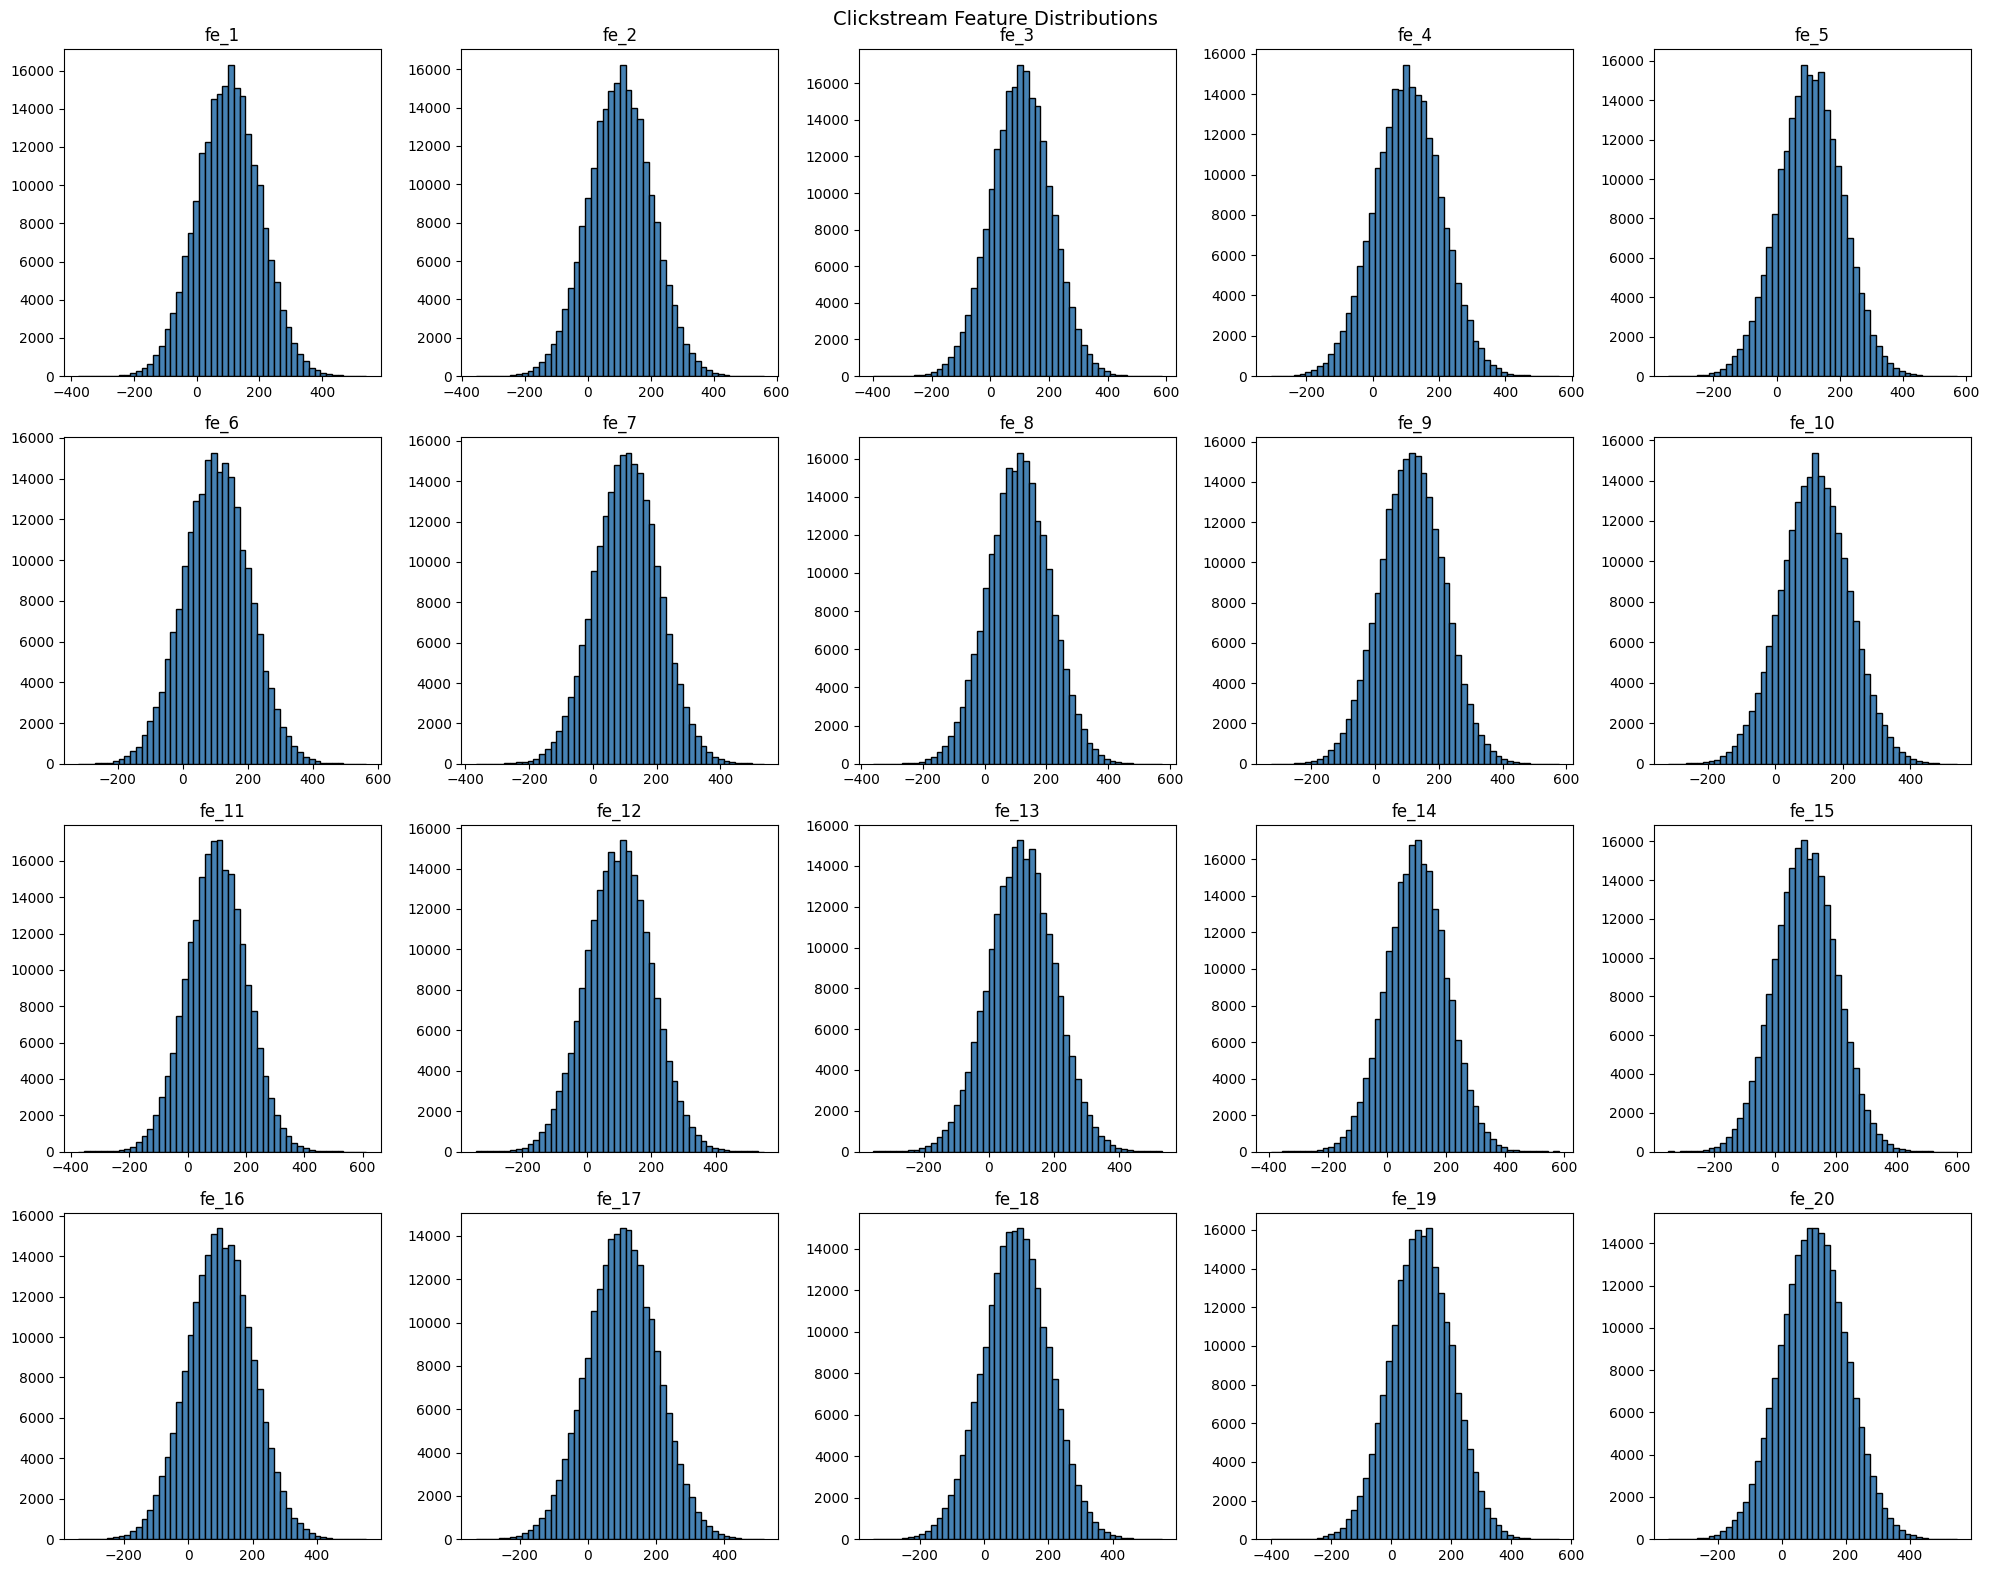

In [6]:
# ---- Basic EDA: Clickstream table ----
click_df = df
print(f"Shape: {click_df.count()} rows x {len(click_df.columns)} columns")

print("\nSchema:")
click_df.printSchema()

# Missing values per column
miss = click_df.select([
    F.sum(F.when(F.col(c).isNull() | (F.col(c).cast("string") == ""), 1).otherwise(0)).alias(c)
    for c in click_df.columns
]).toPandas().T.rename(columns={0: "null_or_empty"})
print("Missing (null or empty) per column:")
print(miss, "\n")

# Cardinality
dist = click_df.select([
    F.countDistinct(F.col(c)).alias(c) for c in click_df.columns
]).toPandas().T.rename(columns={0: "distinct"})
print("Distinct values per column:")
print(dist, "\n")

# Date coverage
click_df.select(
    F.min("snapshot_date").alias("snapshot_min"),
    F.max("snapshot_date").alias("snapshot_max"),
).show()

# Summary statistics for feature columns
feature_cols = [f"fe_{i}" for i in range(1, 21)]
click_pdf = click_df.select(feature_cols).toPandas()
print("Feature summary statistics:")
print(click_pdf.describe().T, "\n")

# Distribution histograms
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()
for ax, c in zip(axes, feature_cols):
    ax.hist(click_pdf[c].dropna(), bins=50, color="steelblue", edgecolor="black")
    ax.set_title(c)
plt.suptitle("Clickstream Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()